# 1. Reading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv('exams.csv')
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']

# 2. Task type

I am trying to predict total_score => my task is regression.

# 3. Preprocessing

I will not normalize because there are no numerical columns in X

In [2]:
X = df.drop(['math score', 'reading score', 'writing score', 'total_score'], axis=1)
y = df['total_score']

categorical_features = X.columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape)
print(X_test_processed.shape)

(800, 17)
(200, 17)


# 4. Training

In [3]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(X_train_processed.toarray(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_processed.toarray(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/tedvtorov/Desktop/py-proj/MISIS/intro_to_ml_course/

Number of training batches: 13
Number of testing batches: 4


# 5. Training

In [ ]:
import torch.nn as nn
import torch.optim as optim

input_size = X_train_tensor.shape[1]
output_size = 1
num_epochs = 100

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.layer1 = nn.Linear(input_size, output_size)
    
    def forward(self, x):
        return self.layer1(x)

class OneHiddenLayerNet(nn.Module):
    def __init__(self):
        super(OneHiddenLayerNet, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(64, output_size)
        
    def forward(self, x):
        x = self.relu(self.layer1(x))
        return self.layer2(x)

class DeepNet(nn.Module):
    def __init__(self):
        super(DeepNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, output_size)
        )
    
    def forward(self, x):
        return self.network(x)


def train_model(model, optimizer, criterion, train_loader, epochs):
    """Function to train the model."""
    model.train()
    for epoch in range(epochs):
        for inputs, labels in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


criterion = nn.MSELoss()

print("Training SimpleNet...")
simple_model = SimpleNet()
sgd_optimizer = optim.SGD(simple_model.parameters(), lr=0.001)
train_model(simple_model, sgd_optimizer, criterion, train_loader, num_epochs)

print("Training OneHiddenLayerNet...")
one_hidden_model = OneHiddenLayerNet()
adam_optimizer_1 = optim.Adam(one_hidden_model.parameters(), lr=0.001)
train_model(one_hidden_model, adam_optimizer_1, criterion, train_loader, num_epochs)

print("Training DeepNet...")
deep_model = DeepNet()
adam_optimizer_2 = optim.Adam(deep_model.parameters(), lr=0.001)
train_model(deep_model, adam_optimizer_2, criterion, train_loader, num_epochs)

print("\nAll models trained.")

Training SimpleNet...
Training OneHiddenLayerNet...
Training DeepNet...

All models trained.


# 6. Loss calculation

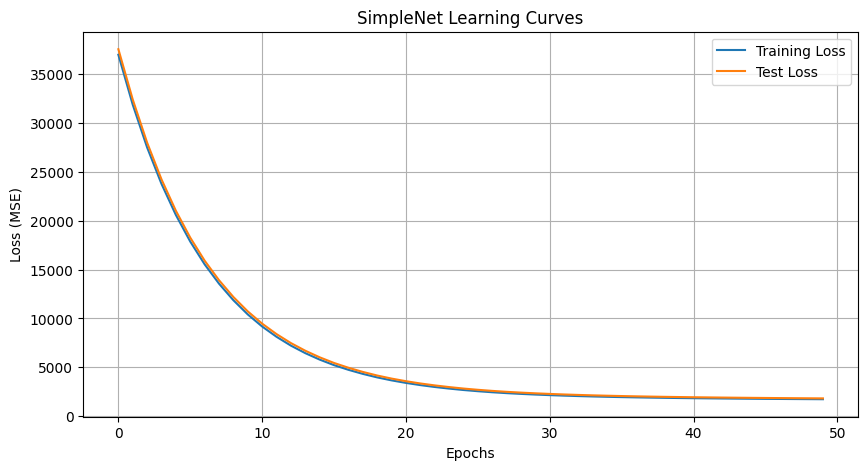

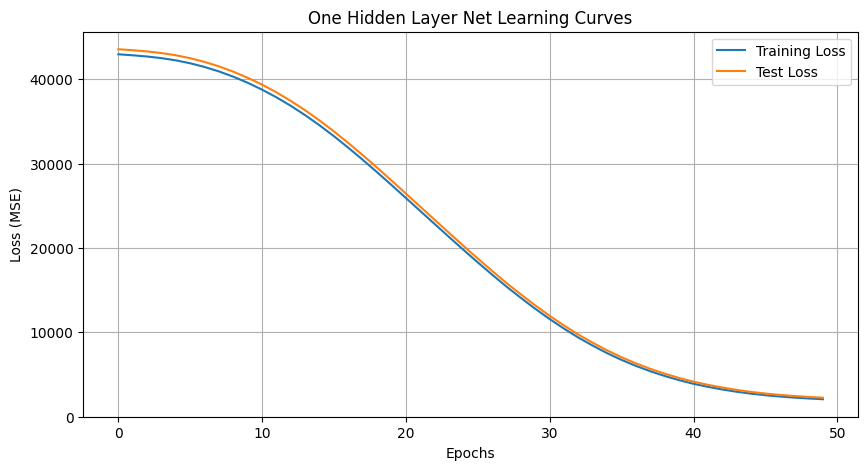

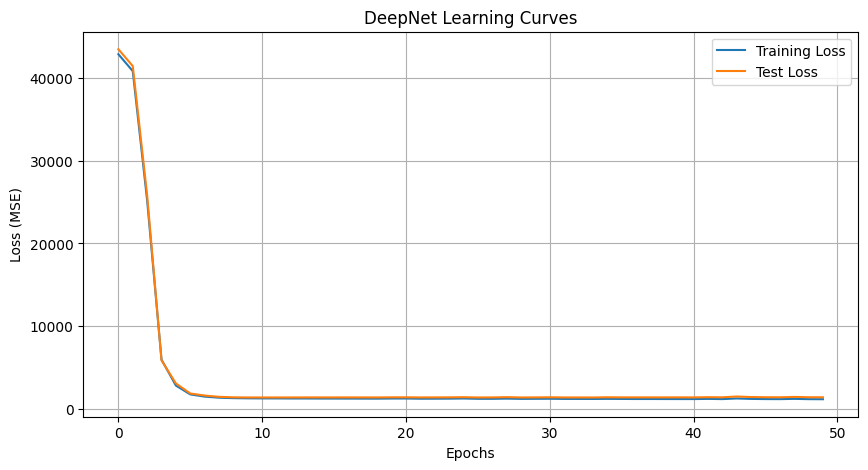

In [5]:
def evaluate_loss(model, loader, criterion):
    """Calculates the model's average loss on a given data loader."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
    return total_loss / len(loader.dataset)

def train_and_get_history(model, optimizer, criterion, train_loader, test_loader, epochs):
    """Trains the model and records loss history for plotting."""
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        train_loss = evaluate_loss(model, train_loader, criterion)
        test_loss = evaluate_loss(model, test_loader, criterion)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
    return train_losses, test_losses

def plot_learning_curves(train_losses, test_losses, title):
    """Plots learning curves from loss history."""
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()


simple_model_hist = SimpleNet()
sgd_optimizer_hist = optim.SGD(simple_model_hist.parameters(), lr=0.001)
s_train_hist, s_test_hist = train_and_get_history(simple_model_hist, sgd_optimizer_hist, criterion, train_loader, test_loader, num_epochs)
plot_learning_curves(s_train_hist, s_test_hist, "SimpleNet Learning Curves")

one_hidden_model_hist = OneHiddenLayerNet()
adam_optimizer_1_hist = optim.Adam(one_hidden_model_hist.parameters(), lr=0.001)
o_train_hist, o_test_hist = train_and_get_history(one_hidden_model_hist, adam_optimizer_1_hist, criterion, train_loader, test_loader, num_epochs)
plot_learning_curves(o_train_hist, o_test_hist, "One Hidden Layer Net Learning Curves")

deep_model_hist = DeepNet()
adam_optimizer_2_hist = optim.Adam(deep_model_hist.parameters(), lr=0.001)
d_train_hist, d_test_hist = train_and_get_history(deep_model_hist, adam_optimizer_2_hist, criterion, train_loader, test_loader, num_epochs)
plot_learning_curves(d_train_hist, d_test_hist, "DeepNet Learning Curves")

# 7. Metrics

In [6]:
def evaluate_mae(model, loader):
    """Evaluates the model's MAE on a given data loader."""
    model.eval()
    total_mae = 0
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs)
            total_mae += torch.abs(outputs - labels).sum().item()
    return total_mae / len(loader.dataset)

train_mae_simple = evaluate_mae(simple_model, train_loader)
test_mae_simple = evaluate_mae(simple_model, test_loader)
print(f"SimpleNet (SGD) -> Train MAE: {train_mae_simple:.2f} | Test MAE: {test_mae_simple:.2f}")

train_mae_one_hidden = evaluate_mae(one_hidden_model, train_loader)
test_mae_one_hidden = evaluate_mae(one_hidden_model, test_loader)
print(f"OneHiddenLayerNet (Adam) -> Train MAE: {train_mae_one_hidden:.2f} | Test MAE: {test_mae_one_hidden:.2f}")

train_mae_deep = evaluate_mae(deep_model, train_loader)
test_mae_deep = evaluate_mae(deep_model, test_loader)
print(f"DeepNet (Adam) -> Train MAE: {train_mae_deep:.2f} | Test MAE: {test_mae_deep:.2f}")

SimpleNet (SGD) -> Train MAE: 33.95 | Test MAE: 35.07
OneHiddenLayerNet (Adam) -> Train MAE: 37.91 | Test MAE: 40.39
DeepNet (Adam) -> Train MAE: 28.52 | Test MAE: 30.70


Deepnet performed the best
no overfitting
simplenet and onehiddenlayernet are underfitting heavily
model metrics can be improved by playing around with learning rate and getting good data